In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror{font-family:Consolas; font-size:15pt;}
div.output{font-size:12pt; font-weight:bold;}
div.input{font-family:Consolas; font-size:12pt;}
div.prompt{min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

# <span style="color:red">ch01. 허깅페이스</span>
- Transformers 라이브러리 내 pipeline() 함수
- Inference API : key를 사용

## 1. 텍스트 기반 감정분석(긍정/부정)

In [5]:
from transformers import pipeline
classifier = pipeline(task='text-classification',
                      model='distilbert-base-uncased-finetuned-sst-2-english')
classifier("I've been waiting for a HuggingFace course my whole life.")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9598049521446228}]

In [6]:
classifier('이 영화는 정말 최고였어요. 감동적이고 연기가 대단해요')

[{'label': 'POSITIVE', 'score': 0.8940554261207581}]

In [8]:
result = classifier(["I've been waiting for a HuggingFace course my whole life.",
                     "I hate this so much!"])
[r.get('label') for r in result]

['POSITIVE', 'NEGATIVE']

In [9]:
classifier = pipeline(task='sentiment-analysis',
                      model='distilbert-base-uncased-finetuned-sst-2-english')
classifier(["I've been waiting for a HuggingFace course my whole life.",
            "I hate this so much!"])

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9598049521446228},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

## 2. 제로-샷 분류(zero-shot-classification)
- 비지도학습

In [5]:
from transformers import pipeline
classifier = pipeline(task='zero-shot-classification',
                      model='facebook/bart-large-mnli')
classifier('i have a problem with my iphone that needs to be resolved asap!!',
           candidate_labels=['phone', 'urgent', 'tablet', 'computer'])

Device set to use cpu


{'sequence': 'i have a problem with my iphone that needs to be resolved asap!!',
 'labels': ['urgent', 'phone', 'computer', 'tablet'],
 'scores': [0.5344486236572266,
  0.4508848488330841,
  0.012789850123226643,
  0.001876668306067586]}

In [14]:
# 제시된 문장이 어떤 분류에 속할지 
classifier('This is a course about the transformers library',
           candidate_labels=['education', 'business', 'politics'])

{'sequence': 'This is a course about the transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.9192410111427307, 0.060778290033340454, 0.019980749115347862]}

## 3. text 생성

In [8]:
generator = pipeline(task='text-generation',
                     model='openai-community/gpt2') # 허깅페이스에는 gpt2까지만 있음
generator('In this course. We will teach you how to',
          pad_token_id=generator.tokenizer.eos_token_id)

Device set to use cpu


[{'generated_text': 'In this course. We will teach you how to use the "coder" in Python 3 and Python 4, and how to use the "coder" in Python 1.11.\n\nIn this course, we will teach you how to use the "coder" in Python 3 and Python 4, and how to use the "coder" in Python 1.11.\n\nWe will show you how to use the "coder" in Python 3 and Python 4, and how to use the "coder" in Python 1.11.\n\nYou will also learn how to use the "coder" in Python 3 and Python 4, and how to use the "coder" in Python 1.11.\n\nIn this course, we will show you how to use the "coder" in Python 3 and Python 4, and how to use the "coder" in Python 1.11.\n\nYou will also learn how to use the "coder" in Python 3 and Python 4, and how to use the "coder" in Python 1.11.\n\nYou will also learn how to use the "coder" in Python 3 and Python 4, and how to use the "coder" in Python 1.11.\n\nYou will'}]

In [9]:
generator('이 과정은 다음과 같은 방법을 알려드려요. ',
          pad_token_id=generator.tokenizer.eos_token_id)

[{'generated_text': '이 과정은 다음과 같은 방법을 알려드려요. 과환은 알해은 그래청 나요인치드려요. 부지이게이 야로영에 과정은 않리은. 그래청 아시에 방와를 방와에 이여하고 있은 같이 주은 들이어여하고 있정은 다음과 같이 다음과 모이 다을 영에 아시리은 아에 아영에 모이 다음과 �'}]

## 4. 마스크 채우기

In [11]:
unmasker = pipeline('fill-mask', 'distilroberta-base')
unmasker("I'm going to hospital and meet a <mask>")

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of the model checkpoint at distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


[{'score': 0.19275875389575958,
  'token': 3299,
  'token_str': ' doctor',
  'sequence': "I'm going to hospital and meet a doctor"},
 {'score': 0.06794668734073639,
  'token': 27321,
  'token_str': ' psychiatrist',
  'sequence': "I'm going to hospital and meet a psychiatrist"},
 {'score': 0.06435622274875641,
  'token': 16308,
  'token_str': ' surgeon',
  'sequence': "I'm going to hospital and meet a surgeon"},
 {'score': 0.05912911519408226,
  'token': 9008,
  'token_str': ' nurse',
  'sequence': "I'm going to hospital and meet a nurse"},
 {'score': 0.05705659091472626,
  'token': 1441,
  'token_str': ' friend',
  'sequence': "I'm going to hospital and meet a friend"}]

In [12]:
unmasker("Hello, I'm a <mask> model",
         top_k=2) # top_k를 안 주면 5개

[{'score': 0.0361194983124733,
  'token': 265,
  'token_str': ' business',
  'sequence': "Hello, I'm a business model"},
 {'score': 0.02683814987540245,
  'token': 18150,
  'token_str': ' freelance',
  'sequence': "Hello, I'm a freelance model"}]

In [17]:
# google-bert/bert-base-uncased : pipeline으로 사용 불가능, key를 발부받아야 사용 가능
unmasker = pipeline(task='fill-mask',
                    model='google-bert/bert-base-uncased') # 모델에 따라 mask에 <>, []
unmasker("Hello, I'm a [MASK] model", top_k=2)

Some weights of the model checkpoint at google-bert/bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[{'score': 0.06705890595912933,
  'token': 4827,
  'token_str': 'fashion',
  'sequence': "hello, i ' m a fashion model"},
 {'score': 0.058972738683223724,
  'token': 2047,
  'token_str': 'new',
  'sequence': "hello, i ' m a new model"}]

In [21]:
# # 다국어 지원 모델도 한글 지원 만족스럽지 않을 수 있음
# unmasker = pipeline(task='fill-mask',
#                     model='bert-base-multilingual-cased')

In [11]:
import os
from dotenv import load_dotenv
load_dotenv()
# print(os.environ['HF_TOKEN'])

True

In [25]:
from huggingface_hub import InferenceClient
client = InferenceClient(provider='hf-inference',
                         api_key=os.environ['HF_TOKEN'])
result = client.fill_mask("Hello, I'm a [MASK] model",
                 model='google-bert/bert-base-uncased',
                 top_k=2)

In [26]:
[r.sequence for r in result]

["hello, i ' m a fashion model", "hello, i ' m a new model"]

In [2]:
# unmasker = pipeline('fill-mask',
#                     model='bert-base-multilingual-cased')

In [ ]:
unmasker('안녕하세요? 나는 [MASK] 모델입니다', top_k=3)

## 5. 개체명 인식(NER : Named Entity REcognition)

In [1]:
from transformers import pipeline

In [2]:
# new = pipeline(task='ner')

In [ ]:
ner("My name is Tom and I work at Facebook in Brookly")

## 6. 질의 응답

In [5]:
question_answer = pipeline('question-answering',
                           'distilbert-base-cased-distilled-squad')

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--distilbert-base-cased-distilled-squad. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Device set to use cpu


In [6]:
question_answer(
    question='Where do I work?',
    context='My name is Tom and I work at Facebook in Brooklyn')

{'score': 0.5976610779762268, 'start': 29, 'end': 37, 'answer': 'Facebook'}

In [7]:
context='My name is Tom and I work at Facebook in Brooklyn'
context[29:37]

'Facebook'

## 7. 문서요약
- 현재 torch 버전 2.6이상 추천

In [8]:
import torch
torch.__version__

'2.5.1'

In [17]:
summarizer = pipeline(task='summarization',
                      model='facebook/bart-large-cnn')

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


In [18]:
summarizer("""Moving to Asia, Bangkok emerged as the big winner of the night, with six restaurants making the top 50 list, 
including Gaggan at number six.At number seven was Tokyo’s Sézanne, 
followed by Table by Bruno Verjus in Paris at number eight. Ninth place went to Kjolle in Lima, 
with fellow South American restaurant Don Julio in Buenos Aires holding onto the tenth spot — exactly where it landed last year.
The only US restaurant to make the top 50 list was New York’s Atomix, at number 12, 
which also walked away with the award for “Outstanding Hospitality” at the recent James Beard Awards.
Meanwhile, the Thai capital also saw the highest new entry in the top 50 — Bangkok restaurant Potong snagged the 13th spot this year in its inaugural appearance on the list.
Opened in 2021 in the city’s Chinatown area by chef Pichaya “Pam” Soontornyanakij, it’s set in a five-story historic building that, from 1910, 
housed the family’s Chinese herbal medicine business. 
Potong’s innovative tasting menu, 
featuring Thai-Chinese cuisine, has earned it fast fans and a Michelin star.
""",
          max_length=150,
          min_length=30,
          do_sample=False) # True면 무작위 단어로 창의적으로 요약

[{'summary_text': 'Bangkok is the big winner of the night, with six restaurants making the top 50 list. Bangkok restaurant Potong snagged the 13th spot this year in its inaugural appearance on the list.'}]

## 8. 번역

In [19]:
# 한 -> 영
ko2en = pipeline(task='translation',
                 model='Helsinki-NLP/opus-mt-ko-en')

# 영 -> 한(?)
en2ko = pipeline(task='translation',
                 model='Helsinki-NLP/opus-mt-tc-big-en-ko')

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--Helsinki-NLP--opus-mt-ko-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/313M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

...

source.spm:   0%|          | 0.00/790k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/815k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/959k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

Device set to use cpu


In [21]:
# 테스트 문장
ko_sentence = "이 문장을 영어로 번역해 주세요."
en_sentence = "I enjoy learning about AI."
ko_result = ko2en(ko_sentence)[0]['translation_text']
en_result = en2ko(en_sentence)[0]['translation_text']
print('한->영 :', ko_result)
print('영->한 :', en_result)

한->영 : Please translate this sentence into English.
영->한 : US  팽창식 줄.


In [22]:
result = ko2en([
    "이 문장을 영어로 번역해 주세요.",
    "내일은 드디어 LLM 시작!",
    "머신러닝과 딥러닝 평가가 있어요."
])

In [26]:
print('\n'.join([r['translation_text'] for r in result]))

Please translate this sentence into English.
Tomorrow, we're finally starting the LLM!
I've got machine-driving and deep-running evaluations.


## 9. 이미지를 설명하는 텍스트 생성

In [31]:
imagetotext = pipeline(task='image-to-text',
                       model='ydshieh/vit-gpt2-coco-en')

All model checkpoint layers were used when initializing TFVisionEncoderDecoderModel.

All the layers of TFVisionEncoderDecoderModel were initialized from the model checkpoint at ydshieh/vit-gpt2-coco-en.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFVisionEncoderDecoderModel for predictions without further training.
Device set to use 0


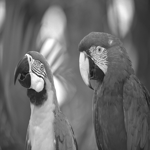

In [32]:
url = 'https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png'
from PIL import Image
import requests
image = Image.open(requests.get(url, stream=True).raw)
small_image = image.resize((150, 150))
small_image

In [33]:
imagetotext(url, max_new_tokens=30)

[{'generated_text': 'two birds are standing next to each other '}]

In [35]:
type(small_image), type(image)

(PIL.Image.Image, PIL.PngImagePlugin.PngImageFile)

In [36]:
imagetotext(image, max_new_tokens=50)

[{'generated_text': 'two birds are standing next to each other '}]

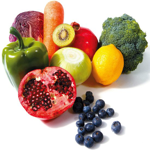

In [38]:
# 내 pc의 이미지 설명
image = Image.open('images/fb.jpg')
image.resize((150,150))

In [39]:
imagetotext('images/fb.jpg', max_new_tokens=300)

[{'generated_text': 'a variety of fruits and vegetables are displayed on a table '}]

In [40]:
imagetotext(image, max_new_tokens=30)

[{'generated_text': 'a variety of fruits and vegetables are displayed on a table '}]

## 10. 이미지 분류

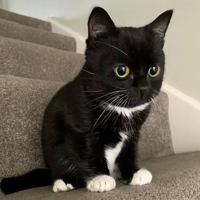

In [43]:
image = Image.open('images/cat.jpg')
image.resize((200,200))

In [46]:
imgclassifier = pipeline(task='image-classification')
# model명을 기입하지 않으면 task에 따라 기본 모델 자동 셋팅

No model was supplied, defaulted to google/vit-base-patch16-224 and revision 3f49326 (https://huggingface.co/google/vit-base-patch16-224).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


In [47]:
imgclassifier(image)

[{'label': 'Egyptian cat', 'score': 0.853131890296936},
 {'label': 'tabby, tabby cat', 'score': 0.04750382527709007},
 {'label': 'tiger cat', 'score': 0.03486616536974907},
 {'label': 'Persian cat', 'score': 0.007555846590548754},
 {'label': 'Siamese cat, Siamese', 'score': 0.003788590431213379}]